# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [142]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [143]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [144]:
#seu código aqui
print (df.dtypes)

customerID             object
Genero                 object
Idoso                   int64
Casado                 object
Dependents             object
Tempo_como_Cliente      int64
PhoneService           object
Servico_Internet       object
Servico_Seguranca      object
Suporte_Tecnico        object
StreamingTV            object
Tipo_Contrato          object
PaymentMethod          object
Pagamento_Mensal      float64
Total_Pago            float64
Churn                  object
dtype: object


In [145]:
df = df.astype({
    'Genero': 'string',
    'Casado': 'string',
    'Dependents': 'string',
    'PhoneService': 'string',
    'Servico_Internet': 'string',
    'Servico_Seguranca': 'string',
    'Suporte_Tecnico': 'string',
    'StreamingTV': 'string',
    'Tipo_Contrato': 'string',
    'PaymentMethod': 'string',
    'Churn': 'string'
})
print (df.dtypes)

customerID                    object
Genero                string[python]
Idoso                          int64
Casado                string[python]
Dependents            string[python]
Tempo_como_Cliente             int64
PhoneService          string[python]
Servico_Internet      string[python]
Servico_Seguranca     string[python]
Suporte_Tecnico       string[python]
StreamingTV           string[python]
Tipo_Contrato         string[python]
PaymentMethod         string[python]
Pagamento_Mensal             float64
Total_Pago                   float64
Churn                 string[python]
dtype: object


# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [146]:
#seu código aqui
(df.isnull().sum()/len(df))*100

customerID             0.00
Genero                 0.48
Idoso                  0.00
Casado                 0.00
Dependents             0.00
Tempo_como_Cliente     0.00
PhoneService          59.28
Servico_Internet       0.00
Servico_Seguranca      0.00
Suporte_Tecnico        0.00
StreamingTV            0.00
Tipo_Contrato          0.00
PaymentMethod          0.00
Pagamento_Mensal      13.00
Total_Pago             0.00
Churn                  0.20
dtype: float64

B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

Escolhi a coluna Pagamento_Mensal para remover as linhas com valores nulos, já que ela tem cerca de 13% de dados faltando no DataFrame. Antes disso, dei uma olhada para ver se essa exclusão poderia afetar a análise. Pelos gráficos de boxplot e histograma, não parece que esses valores nulos vão causar impacto relevante, então a remoção não deve prejudicar os resultados. 

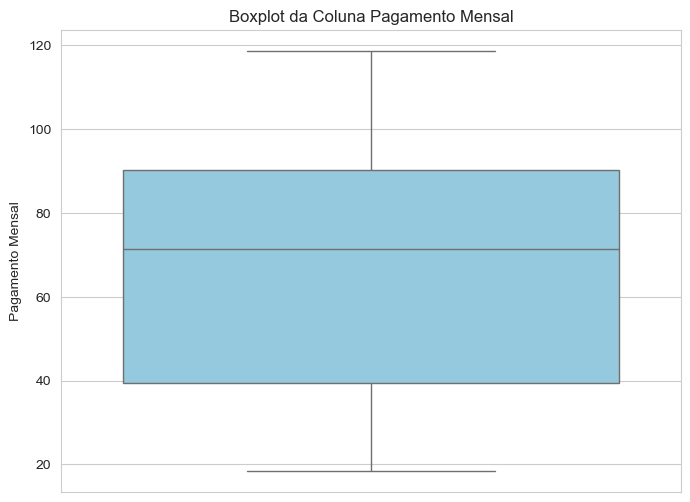

In [147]:
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Pagamento_Mensal', color='skyblue')
plt.title('Boxplot da Coluna Pagamento Mensal')
plt.ylabel('Pagamento Mensal')
plt.show()

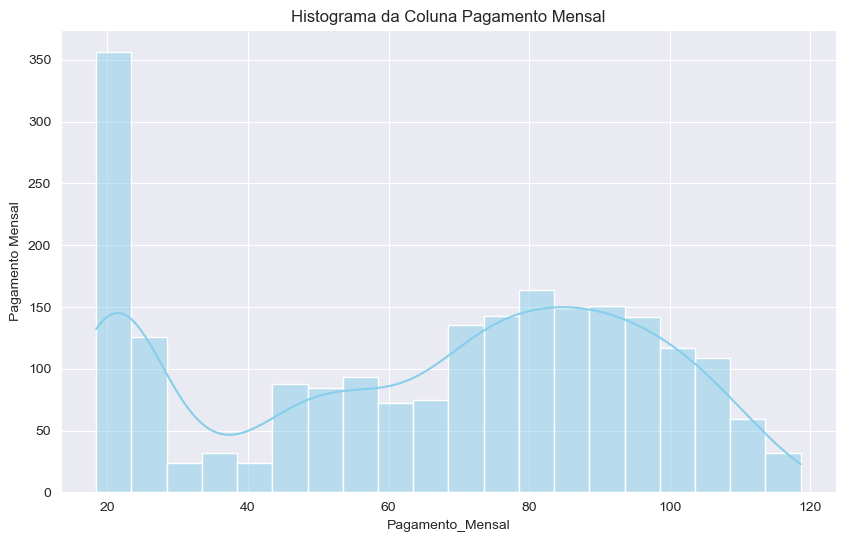

In [148]:
sns.set_style('darkgrid')
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Pagamento_Mensal', bins=20, kde=True, color='skyblue')
plt.title('Histograma da Coluna Pagamento Mensal')
plt.ylabel('Pagamento Mensal')
plt.show()

In [149]:
#seu código aqui
df = df.dropna(subset=['Pagamento_Mensal'])
(df.isnull().sum()/len(df))*100

customerID             0.00000
Genero                 0.00000
Idoso                  0.00000
Casado                 0.00000
Dependents             0.00000
Tempo_como_Cliente     0.00000
PhoneService          60.45977
Servico_Internet       0.00000
Servico_Seguranca      0.00000
Suporte_Tecnico        0.00000
StreamingTV            0.00000
Tipo_Contrato          0.00000
PaymentMethod          0.00000
Pagamento_Mensal       0.00000
Total_Pago             0.00000
Churn                  0.00000
dtype: float64

C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

In [150]:
#seu código aqui
df['PhoneService'] = df['PhoneService'].map({'Yes': 1, 'No': 0})
df['PhoneService'].agg(['mean', 'median'])

mean      0.916279
median    1.000000
Name: PhoneService, dtype: float64

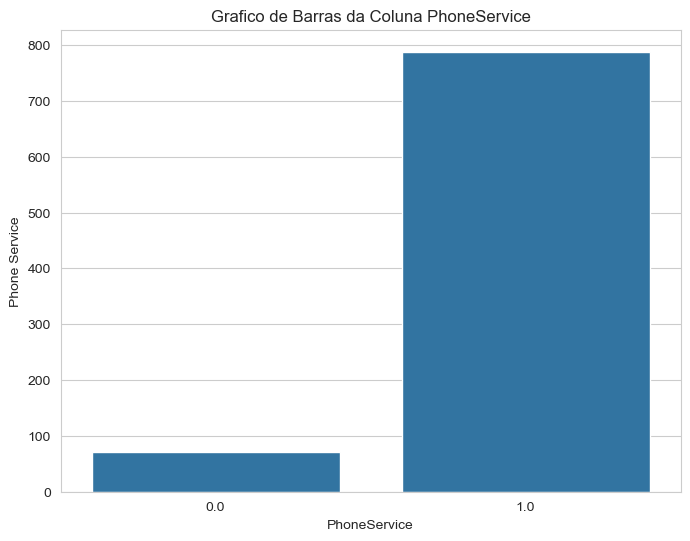

In [151]:
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='PhoneService')
plt.title('Grafico de Barras da Coluna PhoneService')
plt.ylabel('Phone Service')
plt.show()

Na coluna PhoneService, optei por preencher os valores nulos com “Desconhecido”, já que eles representam cerca de 59,21% do DataFrame. Se eu removesse esses dados, perderia mais da metade da base. Como a maior parte dos registros está como nulo, colocar esses valores como “Yes” ou “No” poderia distorcer a análise e levar a uma interpretação errada dos dados.

In [153]:
df['PhoneService'] = df['PhoneService'].fillna('Desconhecido')
df['PhoneService'] = df['PhoneService'].map({1: 'Yes', 0: 'No','Desconhecido': 'Desconhecido'})
df['PhoneService'].value_counts(dropna=False)


PhoneService
Desconhecido    1315
Yes              788
No                72
Name: count, dtype: int64

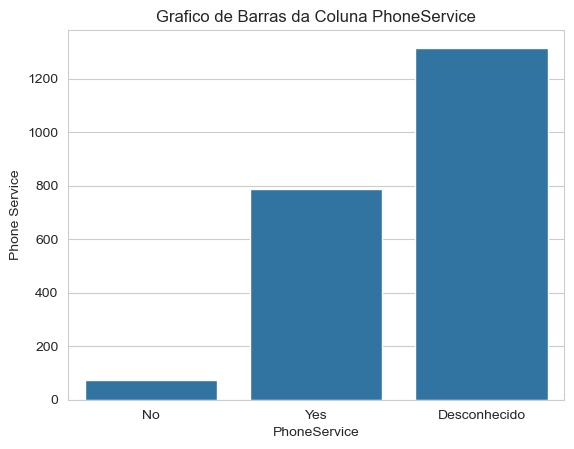

In [154]:
sns.set_style('whitegrid')


sns.countplot(data=df, x='PhoneService')
plt.title('Grafico de Barras da Coluna PhoneService')
plt.ylabel('Phone Service')
plt.show()

df = df.astype({'PhoneService': 'string'})



# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [109]:
#seu código aqui
for col in df.columns:
    print(col, df[col].unique())

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '5702-SKUOB' '1134-YWTYF'
 '6061-GWWAV']
Genero <StringArray>
['Female', 'Male']
Length: 2, dtype: string
Idoso [0 1]
Casado <StringArray>
['Yes', 'No']
Length: 2, dtype: string
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: string
Tempo_como_Cliente [ 1 34  2 23  4 68 38 52 32 29 48 22 43  5 51 71 24 35 54 72  9 69 11 28
 17  8 46  7 36 63 66 41 70 64 37 21 10 16 27 42 58 47 18 33 56 25 61 55
 44 19 20 60  3 40 12 26 49 30  6 13 15  0 67 39 65 50 59 31 45 57 53 14
 62]
PhoneService <StringArray>
['No', 'Yes', 'Desconhecido']
Length: 3, dtype: string
Servico_Internet <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: string
Servico_Seguranca <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: string
Suporte_Tecnico <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: string
StreamingTV <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: string
Tipo_Contrato <Stri

# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [89]:
df.rename(columns={'Dependents': 'Dependentes',
                  'PhoneService': 'Servico_Telefonico',
                  'PaymentMethod': 'Metodo_Pagamento' }, inplace=True)
df.head()

,customerID,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Telefonico,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
300,0895-LMRSF,Male,0,No,No,23,Desconhecido,DSL,No,No,Yes,One year,Bank transfer (automatic),64.90,1509.80,No
301,8098-LLAZX,Female,1,No,No,4,Desconhecido,Fiber optic,No,No,Yes,Month-to-month,Electronic check,95.45,396.10,Yes
